In [1]:
import os
import warnings
from datetime import datetime
from pathlib import Path
import pathlib
from tqdm import tqdm

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from shapely.geometry import Point, box
from scipy import ndimage as ndi
from pyproj import Transformer

import pystac_client
from distributed import LocalCluster

# from dask_gateway import Gateway

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

cluster = LocalCluster(processes=False)
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://10.8.244.48:8787/status,
Dashboard: http://10.8.244.48:8787/status,Workers: 1
Total threads: 16,Total memory: 98.23 GiB
Status: running,Using processes: False
Comm: inproc://10.8.244.48/591348/1,Workers: 0
Dashboard: http://10.8.244.48:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: inproc://10.8.244.48/591348/4,Total threads: 16
Dashboard: http://10.8.244.48:38363/status,Memory: 98.23 GiB
Nanny: None,


2025-10-16 09:12:52,372 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('concatenate-b41f8fd6de98603b7dfe54e7480096d3', 156, 4, 1) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('concatenate-b41f8fd6de98603b7dfe54e7480096d3', 156, 4, 1)->('getitem-open_dataset-scl-original-concatenate-b41f8fd6de98603b7dfe54e7480096d3', 156, 4, 1))
new run_spec: Alias(('concatenate-b41f8fd6de98603b7dfe54e7480096d3', 156, 4, 1)->('getitem-open_dataset-scl-concatenate-b41f8fd6de98603b7dfe54e7480096d3', 156, 4, 1))
old dependencies: {('getitem-open_dataset-scl-original-concatenate-b41f8fd6de98603b7dfe54e748009

In [2]:
def extract_time(ds):
    date_format = "%Y%m%dT%H%M%S"
    filename = ds.encoding["source"]
    date_str = os.path.basename(filename).split("_")[2]
    time = datetime.strptime(date_str, date_format)
    return ds.assign_coords(time=time)


def compute_ndvi_dataset(ds):
    """Compute NDVI for entire dataset."""
    nir = ds.b08.astype("float32")
    red = ds.b04.astype("float32")
    ndvi = (nir - red) / (nir + red)
    ndvi = ndvi.where((nir + red) != 0, np.nan)
    return ndvi


OUT_BASE = pathlib.Path("outputs/samples_zarr")
OUT_BASE.mkdir(parents=True, exist_ok=True)

spatial_extent = {
    "west": 3.2865,
    "south": 50.7589,
    "east": 3.7752,
    "north": 50.9842,
}

bbox_4326 = [
    spatial_extent["west"],
    spatial_extent["south"],
    spatial_extent["east"],
    spatial_extent["north"],
]


transformer = Transformer.from_crs("EPSG:4326", "EPSG:32631", always_xy=True)
west_utm, south_utm = transformer.transform(
    spatial_extent["west"], spatial_extent["south"]
)
east_utm, north_utm = transformer.transform(
    spatial_extent["east"], spatial_extent["north"]
)

# Spatial slice parameters
x_slice = slice(west_utm, east_utm)
y_slice = slice(north_utm, south_utm)

# Connect to the STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Search for Sentinel-2 L2A items within a specific bounding box and date range
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_4326,
    datetime="2018-11-01/2020-02-01",
)

# Retrieve the list of matching items
items = list(search.items())
hrefs = [item.assets["product"].href for item in items]

datacube = xr.open_mfdataset(
    hrefs,
    engine="zarr",
    chunks={},
    group="/measurements/reflectance/r10m",
    concat_dim="time",
    combine="nested",
    preprocess=extract_time,
    mask_and_scale=True,
).sortby("time", ascending=True)

scl = xr.open_mfdataset(
    hrefs,
    engine="zarr",
    chunks={},
    group="/conditions/mask/l2a_classification/r20m",  # Adjust if necessary
    concat_dim="time",
    combine="nested",
    preprocess=extract_time,
    mask_and_scale=True,
).sortby("time", ascending=True)[["scl"]]


b11 = xr.open_mfdataset(
    hrefs,
    engine="zarr",
    chunks={},
    group="/measurements/reflectance/r20m",  # Adjust if necessary
    concat_dim="time",
    combine="nested",
    preprocess=extract_time,
    mask_and_scale=True,
).sortby("time", ascending=True)[["b11"]]

crops = {"maize": 1200, "potatos": 5100, "sugarbeet": 8100, "barley": 1500, "soy": 4100}
crop_samples = {
    name: gpd.read_file("resources/" + name + "_2019.geojson")
    for name, code in crops.items()
}

datacube = datacube.rio.write_crs("EPSG:32631")  # ensure CRS

datacube

<xarray.Dataset> Size: 691GB
Dimensions:      (time: 179, y: 10980, x: 10980)
Coordinates:
  * x            (x) float32 44kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
  * y            (y) float32 44kB 5.7e+06 5.7e+06 5.7e+06 ... 5.59e+06 5.59e+06
  * time         (time) datetime64[ns] 1kB 2018-11-02T10:52:09 ... 2020-01-31...
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 173GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 173GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 173GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 173GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [3]:
# --- helpers ---
def _raster_bounds_polygon_32631(ds):
    """Shapely box of the datacube extent (expects x/y in EPSG:32631)."""
    xmin = float(ds.x.min())
    xmax = float(ds.x.max())
    ymin = float(ds.y.min())
    ymax = float(ds.y.max())
    return box(min(xmin, xmax), min(ymin, ymax), max(xmin, xmax), max(ymin, ymax))


def _random_point_in_geom(geom, rng=None, max_tries=10_000):
    """Rejection sample one point inside (multi)polygon."""
    if rng is None:
        rng = np.random.default_rng()
    minx, miny, maxx, maxy = geom.bounds
    for _ in range(max_tries):
        x = rng.uniform(minx, maxx)
        y = rng.uniform(miny, maxy)
        p = Point(x, y)
        if geom.contains(p):
            return p
    raise RuntimeError("Failed to sample a point inside geometry within max_tries.")


def simple_random_sampling_within_bounds(
    crop_samples, datacube, points_per_crop=5, buffer_m=20
):
    """
    Simple random sampling: find polygons within datacube bounds and pick 5 random points from them.
    Returns {crop_name: GeoJSON FeatureCollection (EPSG:32631)}
    """
    # Get datacube bounds
    raster_poly = _raster_bounds_polygon_32631(datacube)

    points_per_type = {}

    for crop_name, gdf in crop_samples.items():
        # Ensure we have a valid GeoDataFrame with geometry
        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:4326")
        if gdf.crs.to_epsg() != 32631:
            gdf = gdf.to_crs("EPSG:32631")

        # Find polygons that intersect with datacube bounds
        polygons_within_bounds = []
        for idx, geometry in enumerate(gdf.geometry):
            if geometry.intersects(raster_poly):
                polygons_within_bounds.append((idx, geometry))

        if not polygons_within_bounds:
            print(
                f"Warning: No polygons for {crop_name} intersect with datacube bounds"
            )
            continue

        print(
            f"{crop_name}: {len(polygons_within_bounds)} polygons within datacube bounds"
        )

        # If we have polygons within bounds, pick one that fits well
        selected_polygons = []
        for idx, geometry in polygons_within_bounds:
            # Check if this polygon is mostly within the datacube bounds
            intersection = geometry.intersection(raster_poly)
            if (
                intersection.area > 0.5 * geometry.area
            ):  # At least 50% of polygon is within bounds
                selected_polygons.append((idx, geometry))
                # If we found one good polygon, use it for all 5 points
                if len(selected_polygons) >= 1:  # Just need one good polygon
                    break

        if not selected_polygons:
            # If no polygon is mostly within bounds, use the largest intersection
            largest_area = 0
            best_polygon = None
            for idx, geometry in polygons_within_bounds:
                intersection = geometry.intersection(raster_poly)
                if intersection.area > largest_area:
                    largest_area = intersection.area
                    best_polygon = (idx, geometry)
            if best_polygon:
                selected_polygons = [best_polygon]

        if not selected_polygons:
            print(f"Warning: No suitable polygon found for {crop_name}")
            continue

        # Use the first selected polygon to sample all 5 points
        poly_idx, selected_polygon = selected_polygons[0]
        print(
            f"Using polygon {poly_idx} for {crop_name} (area: {selected_polygon.area:.0f} m²)"
        )

        # Sample 5 random points from this single polygon
        buffered_points = []
        for i in range(points_per_crop):
            random_point = _random_point_in_geom(selected_polygon)
            buffered_point = random_point.buffer(buffer_m)
            buffered_points.append(buffered_point)

        # Create GeoDataFrame with buffered points
        result_gdf = gpd.GeoDataFrame(
            {
                "name": [crop_name] * len(buffered_points),
                "geometry": buffered_points,
                "polygon_index": [poly_idx]
                * len(buffered_points),  # Track which polygon was used
                "point_index": list(range(len(buffered_points))),  # Track point number
            },
            crs="EPSG:32631",
        )

        # Convert to GeoJSON string
        points_per_type[crop_name] = result_gdf.to_json()

    return points_per_type

In [4]:
def _sanitize_netcdf_attrs(ds: xr.Dataset) -> xr.Dataset:
    """
    Remove or stringify attrs that netCDF can't store (e.g., dicts, custom objects).
    Also drops private attrs starting with '_' (like '_eopf_attrs') to be safe.
    """

    def clean(mapping):
        bad_keys = []
        for k, v in list(mapping.items()):
            if k.startswith("_"):
                bad_keys.append(k)
                continue
            if isinstance(
                v, (str, bytes, int, float, bool, np.number, np.ndarray, list, tuple)
            ):
                # ok
                continue
            # dicts or anything else: either drop or stringify; here we drop
            bad_keys.append(k)
        for k in bad_keys:
            mapping.pop(k, None)

    ds = ds.copy(deep=False)
    clean(ds.attrs)
    for name, da in ds.variables.items():
        clean(da.attrs)
    return ds


def _align_to_datacube_grid(dc: xr.Dataset, x: float, y: float):
    """Return the nearest datacube x/y coordinates and their integer indices."""
    # nearest index lookup (works lazily with Dask)
    ix = int(abs(dc.x - x).argmin())
    iy = int(abs(dc.y - y).argmin())
    xg = float(dc.x.isel(x=ix))
    yg = float(dc.y.isel(y=iy))
    return ix, iy, xg, yg


def _subset_window(dc: xr.Dataset, x: float, y: float, buffer_m: float | int):
    """Subset a small x/y window around (x,y) from datacube using a metric buffer."""
    if buffer_m is None or buffer_m <= 0:
        # one pixel only
        ix, iy, xg, yg = _align_to_datacube_grid(dc, x, y)
        return dc.isel(x=slice(ix, ix + 1), y=slice(iy, iy + 1))
    # convert meters to number of 10 m pixels (ceil and add margin)
    px = int(np.ceil(buffer_m / 10.0))
    ix, iy, xg, yg = _align_to_datacube_grid(dc, x, y)
    xs = slice(max(ix - px, 0), ix + px + 1)
    ys = slice(max(iy - px, 0), iy + px + 1)
    return dc.isel(x=xs, y=ys)


def _interp_like_local(
    src: xr.Dataset | xr.DataArray, like: xr.Dataset
) -> xr.Dataset | xr.DataArray:
    """Cheap local resampling: resample only to the tiny 'like' grid."""
    # Use nearest to avoid introducing NaNs on tiny windows; it’s fast and robust
    return src.interp_like(like, method="nearest")


# Clouds & shadows (Sentinel-2 SCL): 3=Shadow, 8=Cloud medium, 9=Cloud high, 10=Thin cirrus, 11=Snow/Ice
BAD_SCL = [3, 8, 9, 10, 11]


def apply_simple_scl_mask(ds: xr.Dataset) -> xr.Dataset:
    if "scl" not in ds:  # if you didn't load SCL into the local window, do nothing
        return ds
    bad = ds["scl"].isin(BAD_SCL)
    out = ds.drop_vars("scl")  # keep only reflectances
    # mask each band where bad==True
    for v in out.data_vars:
        da = out[v]
        if np.issubdtype(da.dtype, np.integer):
            da = da.astype("float32")
        out[v] = da.where(~bad)
    return out


def _combine_and_reduce(
    dc_win: xr.Dataset, scl_win: xr.Dataset, b11_win: xr.Dataset, reduce: str = "median"
):
    """
    Combine bands and reduce spatial dims to a single time series.
    reduce: 'median' | 'mean' | 'nearest'
    """
    ds = xr.Dataset(
        {
            "b04": dc_win["b04"],
            "b08": dc_win["b08"],
            "b11": b11_win["b11"],
            "scl": scl_win["scl"],
        }
    )
    # NDVI
    ds = apply_simple_scl_mask(ds)
    ndvi = (ds.b08.astype("float32") - ds.b04.astype("float32")) / (ds.b08 + ds.b04)
    ndvi = ndvi.where((ds.b08 + ds.b04) != 0)
    ds = ds.assign(ndvi=ndvi)

    # collapse x,y to single point series
    if reduce == "nearest":
        ds = ds.isel(x=0, y=0)
    elif reduce == "mean":
        ds = ds.mean(dim=("y", "x"), skipna=True)
    else:
        ds = ds.median(dim=("y", "x"), skipna=True)

    return ds


def _geojsons_to_point_df(points_per_type: dict[str, str]) -> gpd.GeoDataFrame:
    """Turn your {crop: geojson_str} into a single EPSG:32631 GeoDataFrame with columns: name, point_index, geometry."""
    rows = []
    for crop, gj in points_per_type.items():
        gdf = gpd.read_file(gj)
        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:32631")
        elif gdf.crs.to_epsg() != 32631:
            gdf = gdf.to_crs("EPSG:32631")
        # Your sampling produced buffered polygons; use their centroids as the 'point'
        gdf = gdf.assign(
            name=crop, point_index=gdf.get("point_index", pd.Series(range(len(gdf))))
        )
        gdf["geometry"] = gdf.geometry.centroid
        rows.append(gdf[["name", "point_index", "geometry"]])
    if not rows:
        return gpd.GeoDataFrame(
            columns=["name", "point_index", "geometry"], crs="EPSG:32631"
        )
    return pd.concat(rows, ignore_index=True)


def extract_point_series_for_crops(
    datacube: xr.Dataset,
    scl: xr.Dataset,
    b11: xr.Dataset,
    points_per_type: dict[str, str],
    fallback_buffer_m: int = 20,
    reduce: str = "median",
    out_dir: pathlib.Path | str = "outputs/samples_netcdf",
) -> dict[tuple[str, int], str]:
    """
    For each crop point:
      1) try point-only resample (1 pixel)
      2) if any band is entirely NaN through time, retry with fallback_buffer_m window
      3) reduce to 1-D time series and save as <crop>_<seq>.nc (no appends)
    Returns {(crop, original_point_index): path}
    """
    out_dir = pathlib.Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    pts = _geojsons_to_point_df(points_per_type)
    if pts.empty:
        warnings.warn("No points to process.")
        return {}

    # ensure CRS is written (already done in your script)
    datacube = datacube.rio.write_crs("EPSG:32631")
    scl = scl.rio.write_crs("EPSG:32631")
    b11 = b11.rio.write_crs("EPSG:32631")

    results: dict[tuple[str, int], str] = {}
    # keep a per-crop sequential counter to guarantee 1..N filenames
    per_crop_counter: dict[str, int] = {}

    for _, row in tqdm(pts.iterrows(), total=len(pts), desc="Processing points"):
        crop = str(row["name"])
        pidx = int(row["point_index"])
        x = float(row.geometry.x)
        y = float(row.geometry.y)

        # 1) single-pixel attempt (cheapest)
        dc_win = _subset_window(datacube, x, y, buffer_m=0)
        scl_loc = _interp_like_local(scl, dc_win)
        b11_loc = _interp_like_local(b11, dc_win)
        ds_point = _combine_and_reduce(dc_win, scl_loc, b11_loc, reduce="nearest")

        # Check NaNs across key vars
        needs_fallback = False
        for var in ["b04", "b08", "b11"]:
            da = ds_point[var]
            if da.isnull().all():
                needs_fallback = True
                break

        # 2) fallback with small spatial window if needed
        if needs_fallback and fallback_buffer_m and fallback_buffer_m > 0:
            dc_win = _subset_window(datacube, x, y, buffer_m=fallback_buffer_m)
            scl_loc = _interp_like_local(scl, dc_win)
            b11_loc = _interp_like_local(b11, dc_win)
            ds_point = _combine(dc_win, scl_loc, b11_loc, reduce="median")

        # Determine sequential index (1..N) per crop for filename
        seq = per_crop_counter.get(crop, 0) + 1
        per_crop_counter[crop] = seq

        # Write a separate file, never append
        out_path = out_dir / f"{crop}_{seq}.nc"

        # This is a tiny dataset; persist shrinks the task graph
        ds_write = ds_point.persist()
        ds_write = _sanitize_netcdf_attrs(ds_write)

        # Overwrite if exists to keep clean, and write only this point
        ds_write.to_netcdf(out_path, mode="w")

        results[(crop, pidx)] = str(out_path)
        print(f"[{crop}:{pidx} -> seq {seq}] wrote {out_path}")

    return results

In [5]:
# Simplest way - creates everything automatically
"""
gate = Gateway()
cluster = gate.new_cluster()
cluster
"""

'\ngate = Gateway()\ncluster = gate.new_cluster()\ncluster\n'

In [6]:
# Use the simple sampling
points_per_type = simple_random_sampling_within_bounds(
    crop_samples=crop_samples, datacube=datacube, points_per_crop=5, buffer_m=20
)

print(points_per_type.keys())

maize: 3 polygons within datacube bounds
Using polygon 1 for maize (area: 57299 m²)
potatos: 7 polygons within datacube bounds
Using polygon 1 for potatos (area: 3429 m²)
sugarbeet: 6 polygons within datacube bounds
Using polygon 0 for sugarbeet (area: 17616 m²)
barley: 7 polygons within datacube bounds
Using polygon 0 for barley (area: 26619 m²)
soy: 8 polygons within datacube bounds
Using polygon 0 for soy (area: 1302 m²)
dict_keys(['maize', 'potatos', 'sugarbeet', 'barley', 'soy'])


In [8]:
# This step takes a lots of time to run in our local VM!
"""
# Extract + save time-series per crop (1 sample per crop as configured)
saved = extract_point_series_for_crops(
    datacube=datacube,
    scl=scl,
    b11=b11,
    points_per_type=points_per_type,
    fallback_buffer_m=20,   # try single pixel first, then 20 m window if needed
    out_dir="outputs/samples_netcdf"
)

print("Saved files:", saved)

"""

'\n# Extract + save time-series per crop (1 sample per crop as configured)\nsaved = extract_point_series_for_crops(\n    datacube=datacube,\n    scl=scl,\n    b11=b11,\n    points_per_type=points_per_type,\n    fallback_buffer_m=20,   # try single pixel first, then 20 m window if needed\n    out_dir="outputs/samples_netcdf"\n)\n\nprint("Saved files:", saved)\n\n'

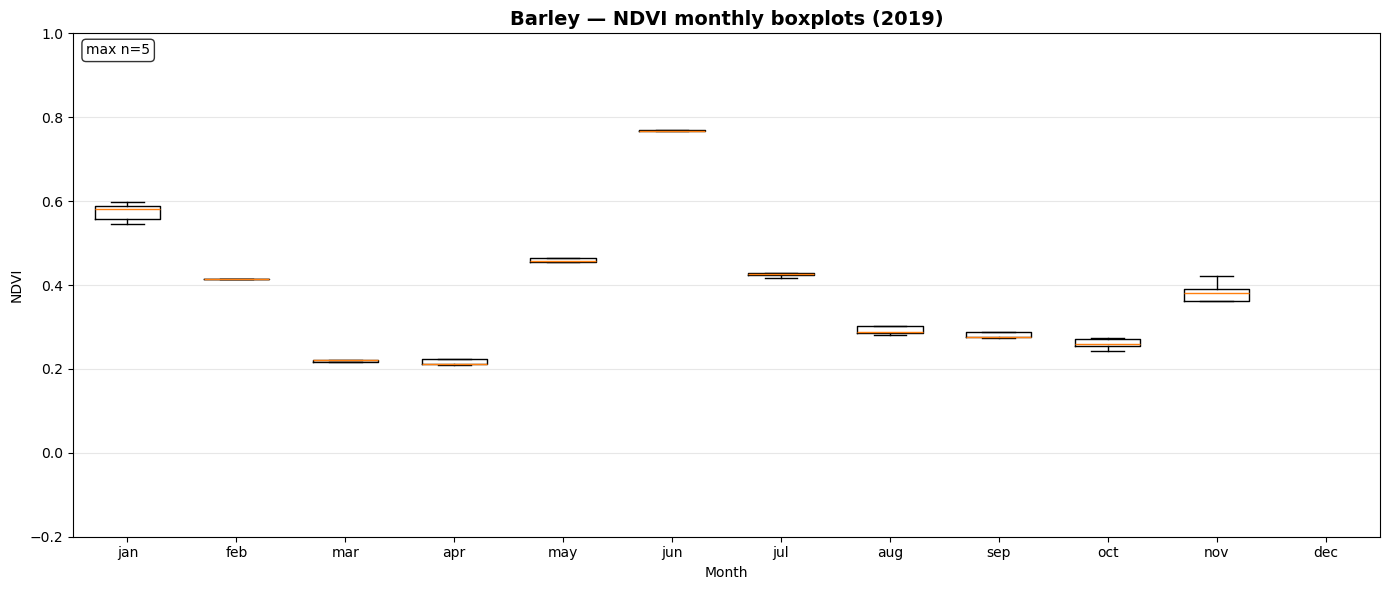

Saved: outputs/ndvi_boxplots/ndvi_boxplot_barley_2019.png


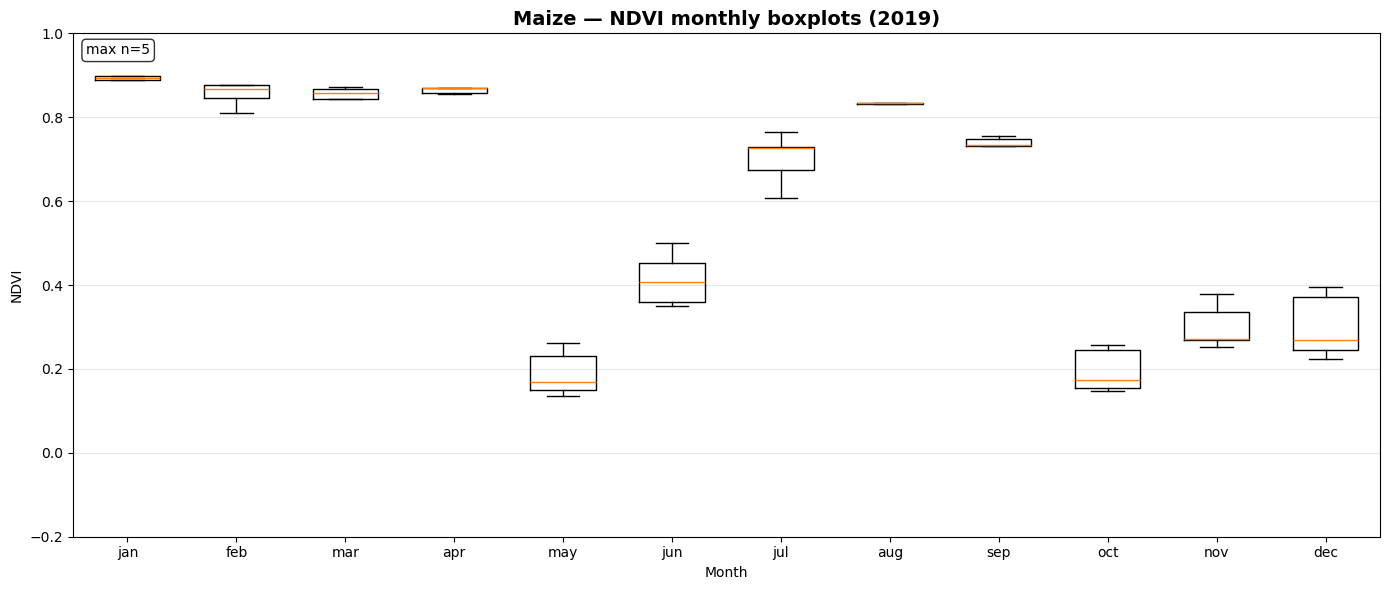

Saved: outputs/ndvi_boxplots/ndvi_boxplot_maize_2019.png


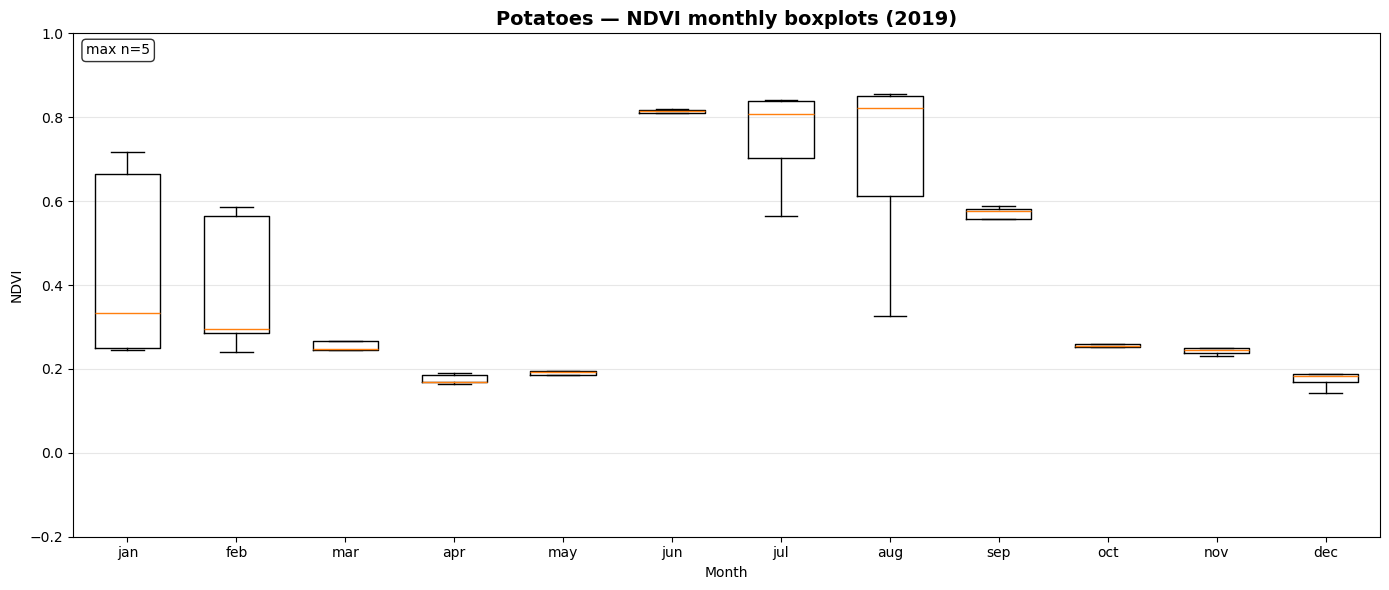

Saved: outputs/ndvi_boxplots/ndvi_boxplot_potatoes_2019.png


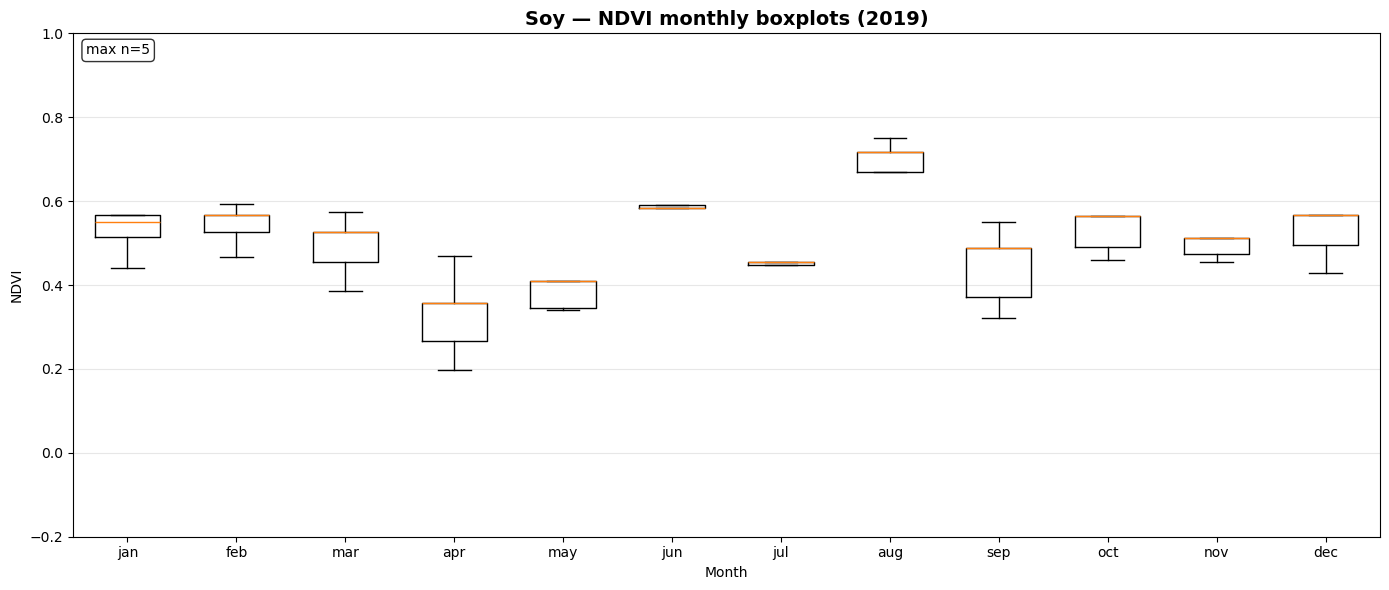

Saved: outputs/ndvi_boxplots/ndvi_boxplot_soy_2019.png


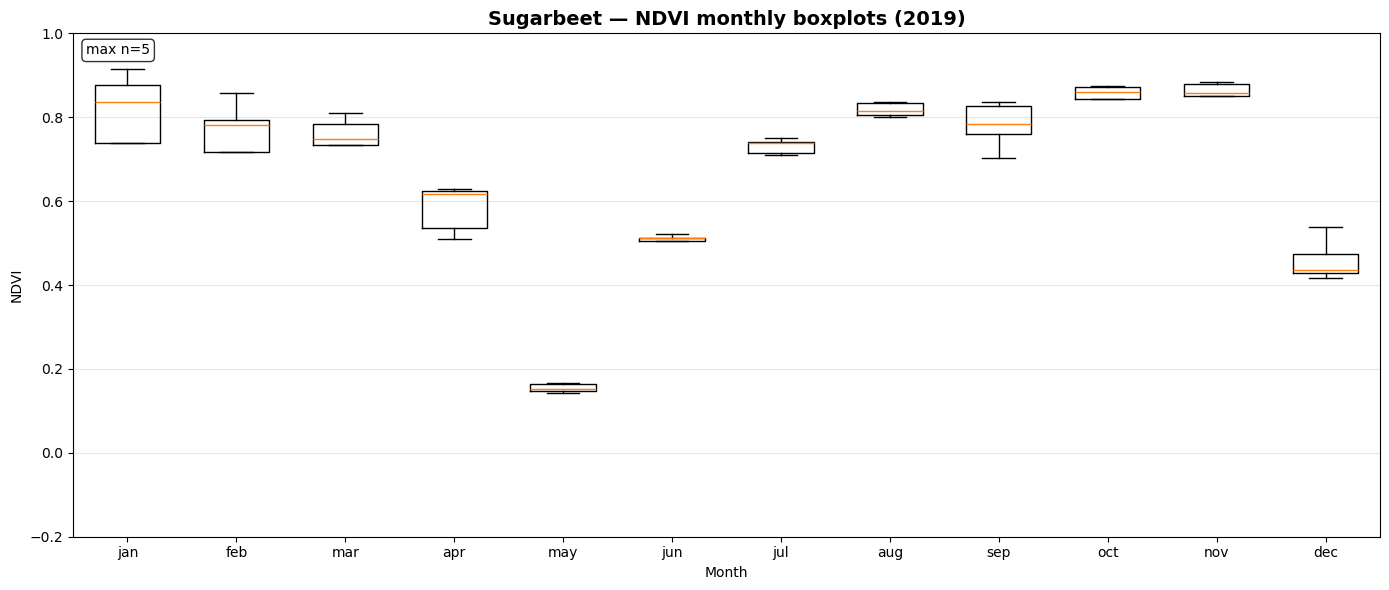

Saved: outputs/ndvi_boxplots/ndvi_boxplot_sugarbeet_2019.png


In [9]:
months = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]


def _monthly_ndvi_series(ds, year):
    """Return a 12-length array of monthly NDVI means (NaN where missing) for given year."""
    if "ndvi" not in ds.data_vars:
        return [np.nan] * 12

    ndvi = ds["ndvi"]
    if "time" not in ndvi.dims or ndvi.time.size == 0:
        return [np.nan] * 12

    time_values = pd.to_datetime(ndvi.time.values)
    values = np.asarray(ndvi.values, dtype=float)

    # Build a pandas Series and resample to month starts
    s = pd.Series(values, index=time_values)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        monthly = s.resample("MS").mean()  # monthly mean from available obs

    # Align to full year
    full = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq="MS")
    out = []
    for t in full:
        v = monthly.get(t, np.nan)
        out.append(np.nan if pd.isna(v) else float(v))
    return out  # length 12


def prep_ndvi_boxplot_df(results_dict, year):
    rows = []
    for (crop_type, point_idx), file_path in results_dict.items():
        try:
            ds = xr.open_dataset(file_path)
        except Exception as e:
            print(f"Skip {file_path}: {e}")
            continue

        try:
            monthly12 = _monthly_ndvi_series(ds, year)
        finally:
            ds.close()

        for month_idx, v in enumerate(monthly12, start=1):
            rows.append(
                {
                    "Crop": crop_type,
                    "MonthIdx": month_idx,
                    "Month": months[month_idx - 1],
                    "Iteration": f"{crop_type}_{point_idx}",
                    "NDVI": v,
                }
            )
    df = pd.DataFrame(rows)
    # Keep only the target year’s rows (already ensured), drop all-NaN rows cleanly
    return df


def create_ndvi_boxplots(results_dict, year=2019, save_dir="outputs/ndvi_boxplots"):
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    df = prep_ndvi_boxplot_df(results_dict, year)

    if df.empty or df["NDVI"].notna().sum() == 0:
        print("No NDVI data available to plot.")
        return

    crops = sorted(df["Crop"].unique())
    for crop in crops:
        sub = df[(df["Crop"] == crop) & df["NDVI"].notna()].copy()
        if sub.empty:
            print(f"No NDVI data for {crop}")
            continue

        # Gather per-month arrays (list of arrays length 12)
        month_arrays = []
        counts = []
        for m in range(1, 13):
            vals = sub.loc[sub["MonthIdx"] == m, "NDVI"].values
            vals = vals[~np.isnan(vals)]
            month_arrays.append(vals)
            counts.append(len(vals))

        fig, ax = plt.subplots(figsize=(14, 6))
        bp = ax.boxplot(month_arrays, showfliers=False, widths=0.6, tick_labels=months)

        ax.set_title(
            f"{crop.title()} — NDVI monthly boxplots ({year})",
            fontsize=14,
            fontweight="bold",
        )
        ax.set_xlabel("Month")
        ax.set_ylabel("NDVI")
        # NDVI can be [-1, 1]; tighten a bit while being safe
        y_min = min([-0.2, np.nanmin(sub["NDVI"]) if sub["NDVI"].size else -0.2])
        y_max = max([1.0, np.nanmax(sub["NDVI"]) if sub["NDVI"].size else 1.0])
        ax.set_ylim(y_min, y_max)

        # light grid on y
        ax.yaxis.grid(True, alpha=0.3)

        # annotate max sample count
        ax.text(
            0.01,
            0.98,
            f"max n={max(counts) if counts else 0}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )

        plt.tight_layout()
        out_path = Path(save_dir) / f"ndvi_boxplot_{crop}_{year}.png"
        plt.savefig(out_path, dpi=200)
        plt.show()
        print(f"Saved: {out_path}")


results_dict = {
    # Maize - 30 samples
    ("maize", 0): "outputs/samples_netcdf/maize_1.nc",
    ("maize", 1): "outputs/samples_netcdf/maize_2.nc",
    ("maize", 2): "outputs/samples_netcdf/maize_3.nc",
    ("maize", 3): "outputs/samples_netcdf/maize_4.nc",
    ("maize", 4): "outputs/samples_netcdf/maize_5.nc",
    # Potatoes - 30 samples (corrected spelling from 'potatos' to 'potatoes')
    ("potatoes", 0): "outputs/samples_netcdf/potatos_1.nc",
    ("potatoes", 1): "outputs/samples_netcdf/potatos_2.nc",
    ("potatoes", 2): "outputs/samples_netcdf/potatos_3.nc",
    ("potatoes", 3): "outputs/samples_netcdf/potatos_4.nc",
    ("potatoes", 4): "outputs/samples_netcdf/potatos_5.nc",
    # Sugarbeet - 30 samples
    ("sugarbeet", 0): "outputs/samples_netcdf/sugarbeet_1.nc",
    ("sugarbeet", 1): "outputs/samples_netcdf/sugarbeet_2.nc",
    ("sugarbeet", 2): "outputs/samples_netcdf/sugarbeet_3.nc",
    ("sugarbeet", 3): "outputs/samples_netcdf/sugarbeet_4.nc",
    ("sugarbeet", 4): "outputs/samples_netcdf/sugarbeet_5.nc",
    # Barley - 30 samples
    ("barley", 0): "outputs/samples_netcdf/barley_1.nc",
    ("barley", 1): "outputs/samples_netcdf/barley_2.nc",
    ("barley", 2): "outputs/samples_netcdf/barley_3.nc",
    ("barley", 3): "outputs/samples_netcdf/barley_4.nc",
    ("barley", 4): "outputs/samples_netcdf/barley_5.nc",
    # Soy - 30 samples
    ("soy", 0): "outputs/samples_netcdf/soy_1.nc",
    ("soy", 1): "outputs/samples_netcdf/soy_2.nc",
    ("soy", 2): "outputs/samples_netcdf/soy_3.nc",
    ("soy", 3): "outputs/samples_netcdf/soy_4.nc",
    ("soy", 4): "outputs/samples_netcdf/soy_5.nc",
}

# run
create_ndvi_boxplots(results_dict, year=2019)

In [10]:
def extract_time(ds):
    date_format = "%Y%m%dT%H%M%S"
    filename = ds.encoding["source"]
    date_str = os.path.basename(filename).split("_")[2]
    time = datetime.strptime(date_str, date_format)
    return ds.assign_coords(time=time)


spatial_extent = {
    "west": 3.2865,
    "south": 50.7589,
    "east": 3.7752,
    "north": 50.9842,
}

bbox_4326 = [
    spatial_extent["west"],
    spatial_extent["south"],
    spatial_extent["east"],
    spatial_extent["north"],
]

# Spatial slice parameters
x_slice = slice(549400, 554400)
y_slice = slice(5641500, 5636500)

# Connect to the STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Search for Sentinel-2 L2A items within a specific bounding box and date range
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_4326,
    datetime="2018-11-01/2020-02-01",
)

# Retrieve the list of matching items
items = list(search.items())
hrefs = [item.assets["product"].href for item in items]

In [11]:
%%time
scl = (
    xr.open_mfdataset(
        hrefs,
        engine="zarr",
        chunks={},
        group="/conditions/mask/l2a_classification/r20m",  # Adjust if necessary
        concat_dim="time",
        combine="nested",
        preprocess=extract_time,
        mask_and_scale=True,
    )
    .sortby("time", ascending=True)[["scl"]]
    .sel(x=x_slice, y=y_slice)
    .compute()
)

/home/sdhinakaran/micromamba/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 24.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 5.85 s, sys: 482 ms, total: 6.33 s
Wall time: 31.9 s


In [12]:
valid_classes = [4, 5, 6]
threshold = 0.1

clear_mask = scl["scl"].isin(valid_classes)

clear_fraction = clear_mask.mean(dim=("y", "x")).compute()

mask_good = clear_fraction >= threshold

In [13]:
%%time
datacube_clear = (
    xr.open_mfdataset(
        hrefs,
        engine="zarr",
        chunks={},
        group="/measurements/reflectance/r10m",
        concat_dim="time",
        combine="nested",
        preprocess=extract_time,
        mask_and_scale=True,
    )
    .sortby("time", ascending=True)
    .isel(time=mask_good)
    .sel(x=x_slice, y=y_slice)
    .compute()
)

datacube_clear

/home/sdhinakaran/micromamba/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 29.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 24 s, sys: 7.8 s, total: 31.8 s
Wall time: 1min 2s


<xarray.Dataset> Size: 280MB
Dimensions:  (time: 35, y: 500, x: 500)
Coordinates:
  * x        (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y        (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time     (time) datetime64[ns] 280B 2018-11-02T10:52:09 ... 2020-01-06T10...
Data variables:
    b02      (time, y, x) float64 70MB 0.0295 0.0272 0.0391 ... 0.0304 0.0409
    b03      (time, y, x) float64 70MB 0.063 0.0586 0.0608 ... 0.0406 0.0417
    b04      (time, y, x) float64 70MB 0.0278 0.0263 0.0431 ... 0.0433 0.0474
    b08      (time, y, x) float64 70MB 0.5619 0.506 0.3667 ... 0.134 0.1704

In [14]:
%%time
b11_clear = (
    xr.open_mfdataset(
        hrefs,
        engine="zarr",
        chunks={},
        group="/measurements/reflectance/r20m",  # Adjust if necessary
        concat_dim="time",
        combine="nested",
        preprocess=extract_time,
        mask_and_scale=True,
    )
    .sortby("time", ascending=True)[["b11"]]
    .isel(time=mask_good)
    .sel(x=x_slice, y=y_slice)
    .compute()
)

b11_clear

/home/sdhinakaran/micromamba/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 24.87 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 8.85 s, sys: 743 ms, total: 9.59 s
Wall time: 37.1 s


<xarray.Dataset> Size: 18MB
Dimensions:  (time: 35, y: 250, x: 250)
Coordinates:
  * x        (x) float32 1kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y        (y) float32 1kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time     (time) datetime64[ns] 280B 2018-11-02T10:52:09 ... 2020-01-06T10...
Data variables:
    b11      (time, y, x) float64 18MB 0.1903 0.1765 0.1647 ... 0.1744 0.1653

In [15]:
scl_clear = scl.isel(time=mask_good)
scl_resampled = scl_clear.scl.interp_like(datacube_clear, method="nearest")
b11_resampled = b11_clear.b11.interp_like(datacube_clear, method="nearest")

datacube_clear["scl"] = scl_resampled
datacube_clear["b11"] = b11_resampled

datacube_clear = datacube_clear.rio.write_crs("EPSG:32631")  # ensure CRS

datacube_clear

<xarray.Dataset> Size: 420MB
Dimensions:      (time: 35, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 280B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 70MB 0.0295 0.0272 ... 0.0304 0.0409
    b03          (time, y, x) float64 70MB 0.063 0.0586 0.0608 ... 0.0406 0.0417
    b04          (time, y, x) float64 70MB 0.0278 0.0263 ... 0.0433 0.0474
    b08          (time, y, x) float64 70MB 0.5619 0.506 0.3667 ... 0.134 0.1704
    scl          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan
    b11          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan

In [16]:
datacube_clear.to_dataarray().to_netcdf("datacube_clear.nc")
datacube_clear = xr.open_dataarray("datacube_clear.nc").to_dataset(dim="variable")
datacube_clear

<xarray.Dataset> Size: 420MB
Dimensions:      (time: 35, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 280B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B ...
Data variables:
    b02          (time, y, x) float64 70MB ...
    b03          (time, y, x) float64 70MB ...
    b04          (time, y, x) float64 70MB ...
    b08          (time, y, x) float64 70MB ...
    scl          (time, y, x) float64 70MB ...
    b11          (time, y, x) float64 70MB ...

In [17]:
def circular_kernel(radius: int) -> np.ndarray:
    """Create a 2D circular (disk) kernel with given radius in pixels."""
    r = int(radius)
    y, x = np.ogrid[-r : r + 1, -r : r + 1]
    k = (x * x + y * y) <= (r * r)
    return k.astype(np.float32)


def _dilate_with_convolve(mask_2d: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    Dilate a boolean mask using convolution with a (0/1) kernel.
    Returns a boolean array where any overlap with the kernel sets True.
    """
    if mask_2d.dtype != np.float32:
        mask_2d = mask_2d.astype(np.float32, copy=False)
    # Convolution counts how many True pixels fall under the kernel footprint.
    conv = ndi.convolve(mask_2d, kernel, mode="constant", cval=0.0)
    return conv > 0.0


def mask_scl_dilation_direct(
    ds: xr.Dataset, *, time_band_name: str = "time", scl_band_name: str = "scl"
) -> xr.Dataset:
    """
    Direct implementation of mask_scl_dilation that processes each time step individually.
    """
    if scl_band_name not in ds:
        raise ValueError(
            f"{scl_band_name!r} not found in dataset variables: {list(ds.data_vars)}"
        )

    if time_band_name not in ds.dims:
        raise ValueError(
            f"{time_band_name!r} not found in dataset dimensions: {list(ds.dims)}"
        )

    scl = ds[scl_band_name]

    # Figure out spatial dimensions
    cand_xy = [d for d in ["y", "x"] if d in scl.dims]
    if len(cand_xy) != 2:
        cand_xy = list(scl.dims[-2:])
    ydim, xdim = cand_xy

    # Precompute kernels
    kernel1 = circular_kernel(radius=8).astype(np.float32)
    kernel2 = circular_kernel(radius=100).astype(np.float32)

    bands_to_mask = [v for v in ds.data_vars if v != scl_band_name]

    # Process each time step directly
    time_steps = ds[time_band_name].values
    masked_time_slices = []
    valid_times = []

    for i, time_val in tqdm(
        enumerate(time_steps), total=len(time_steps), desc="Processing time steps"
    ):
        # Extract single time step
        time_slice = ds.sel({time_band_name: time_val})
        scl_slice = scl.sel({time_band_name: time_val})

        # Convert to numpy arrays for direct processing
        scl_2d = scl_slice.values

        # Apply dilation logic directly
        mask1 = (
            (scl_2d != 2)
            & (scl_2d != 4)
            & (scl_2d != 5)
            & (scl_2d != 6)
            & (scl_2d != 7)
        )
        mask2 = (
            (scl_2d == 3)
            | (scl_2d == 8)
            | (scl_2d == 9)
            | (scl_2d == 10)
            | (scl_2d == 11)
        )

        dil1 = _dilate_with_convolve(
            mask1, kernel1
        )  # That problematic step that leads the kernel in the eodc jupyterlab to crash
        dil2 = _dilate_with_convolve(
            mask2, kernel2
        )  # That problematic step that leads the kernel in the eodc jupyterlab to crash
        combined_mask = dil1 | dil2

        # Apply mask to all bands except SCL
        masked_slice = time_slice.copy()
        has_valid_data = False

        for var in bands_to_mask:
            band_data = time_slice[var].values
            if np.issubdtype(band_data.dtype, np.integer):
                # Convert to float to support NaN
                band_data = band_data.astype(np.float32)
                band_data[combined_mask] = np.nan
                masked_slice[var] = ([ydim, xdim], band_data)
            else:
                band_data = band_data.copy()
                band_data[combined_mask] = np.nan
                masked_slice[var] = ([ydim, xdim], band_data)

            # Check if this band has any valid data in this time step
            if not has_valid_data and np.any(~np.isnan(band_data)):
                has_valid_data = True

        # Only keep time steps with valid data
        if has_valid_data:
            masked_time_slices.append(masked_slice)
            valid_times.append(time_val)

    # Reconstruct dataset with only valid time steps
    if masked_time_slices:
        # Combine all valid time slices
        result = xr.concat(masked_time_slices, dim=time_band_name)
        # Ensure time coordinate is preserved correctly
        result[time_band_name] = valid_times
    else:
        # No valid time steps - return empty dataset with same structure
        result = ds.isel({time_band_name: []})

    return result


masked_ds = mask_scl_dilation_direct(
    datacube_clear, time_band_name="time", scl_band_name="scl"
)
masked_ds

Processing time steps: 100%|████████████████████████████████████████████████████████████| 35/35 [11:50<00:00, 20.30s/it]


<xarray.Dataset> Size: 324MB
Dimensions:      (time: 27, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 216B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 54MB nan nan nan nan ... nan nan nan nan
    b03          (time, y, x) float64 54MB nan nan nan nan ... nan nan nan nan
    b04          (time, y, x) float64 54MB nan nan nan nan ... nan nan nan nan
    b08          (time, y, x) float64 54MB nan nan nan nan ... nan nan nan nan
    scl          (time, y, x) float64 54MB nan nan nan nan ... nan nan nan nan
    b11          (time, y, x) float64 54MB nan nan nan nan ... nan nan nan nan

In [18]:
masked_ds.to_dataarray().to_netcdf("masked_ds.nc")
masked_ds_check = xr.open_dataarray("masked_ds.nc").to_dataset(dim="variable")
masked_ds_check

<xarray.Dataset> Size: 324MB
Dimensions:      (time: 27, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 216B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B ...
Data variables:
    b02          (time, y, x) float64 54MB ...
    b03          (time, y, x) float64 54MB ...
    b04          (time, y, x) float64 54MB ...
    b08          (time, y, x) float64 54MB ...
    scl          (time, y, x) float64 54MB ...
    b11          (time, y, x) float64 54MB ...

In [19]:
def compute_ndvi(ds: xr.Dataset) -> xr.DataArray:
    nir = ds["b08"].astype("float32")
    red = ds["b04"].astype("float32")
    num = nir - red
    den = nir + red
    ndvi = xr.where(den != 0, num / den, np.nan)
    ndvi.name = "NDVI"
    return ndvi


ndvi_dataset = compute_ndvi(masked_ds_check)
ndvi_dataset

<xarray.DataArray 'NDVI' (time: 27, y: 500, x: 500)> Size: 27MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 216B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B 0

In [20]:
masked_ds_check["ndvi"] = ndvi_dataset
monthly = masked_ds_check.resample(time="1MS").mean(skipna=True)
full_index = pd.date_range(
    monthly.time.min().values, monthly.time.max().values, freq="1MS"
)
monthly = monthly.reindex(time=full_index)

monthly = monthly.interpolate_na(
    dim="time", method="linear", use_coordinate="time", limit=1
)
monthly["ndvi"] = monthly["ndvi"].clip(0, 1)
monthly = monthly.groupby("time.month").mean("time", skipna=True)
monthly

<xarray.Dataset> Size: 156MB
Dimensions:      (month: 12, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
    spatial_ref  int64 8B 0
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    b02          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    b03          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    b04          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    b08          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    scl          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    b11          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    ndvi         (month, y, x) float32 12MB nan nan nan nan ... nan nan nan nan

In [21]:
def rename_monthly_vars(monthly_ds, varname):
    # monthly_ds[varname] has dims (month, y, x); create a new band dimension with names <var>_<mon>
    arr = monthly_ds[varname]  # (month, y, x)
    arr = arr.assign_coords(month=months)  # label 1..12 with names
    stacked = xr.concat([arr.sel(month=m) for m in months], dim="band")
    stacked = stacked.assign_coords(band=[f"{varname.upper()}_{m}" for m in months])
    return stacked  # (band, y, x)


ndvi_bands = rename_monthly_vars(monthly, "ndvi")  # bands: NDVI_jan..NDVI_dec
b08_bands = rename_monthly_vars(monthly, "b08")  # B08_*
b11_bands = rename_monthly_vars(monthly, "b11")  # B11_*

all_bands = xr.concat([ndvi_bands, b08_bands, b11_bands], dim="band")  # (band, y, x)
all_bands

<xarray.DataArray 'ndvi' (band: 36, y: 500, x: 500)> Size: 72MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
    spatial_ref  int64 8B 0
    month        (band) <U3 432B 'jan' 'feb' 'mar' 'apr' ... 'oct' 'nov' 'dec'
  * band         (band) <U8 1kB 'NDVI_jan' 'NDVI_feb' ... 'B11_nov' 'B11_dec'

In [22]:
ndvi_jan = all_bands.sel(band="NDVI_jan")
ndvi_apr = all_bands.sel(band="NDVI_apr")
ndvi_may = all_bands.sel(band="NDVI_may")
ndvi_jun = all_bands.sel(band="NDVI_jun")
ndvi_jul = all_bands.sel(band="NDVI_jul")
ndvi_aug = all_bands.sel(band="NDVI_aug")
ndvi_sep = all_bands.sel(band="NDVI_sep")
ndvi_oct = all_bands.sel(band="NDVI_oct")
ndvi_nov = all_bands.sel(band="NDVI_nov")

nir_mar = all_bands.sel(band="B08_mar")
nir_may = all_bands.sel(band="B08_may")
nir_jun = all_bands.sel(band="B08_jun")
nir_oct = all_bands.sel(band="B08_oct")
swir_mar = all_bands.sel(band="B11_mar")
swir_apr = all_bands.sel(band="B11_apr")
swir_may = all_bands.sel(band="B11_may")
swir_oct = all_bands.sel(band="B11_oct")

In [23]:
corn = (
    (
        (ndvi_may < ndvi_jun).astype(int)
        + (ndvi_sep > ndvi_nov).astype(int)
        + (((ndvi_jul + ndvi_aug + ndvi_sep) / 3) > 0.7).astype(int)
    )
    == 3
).astype(np.uint8)

barley = (
    (
        (ndvi_apr < ndvi_may).astype(int)
        + ((ndvi_jun / (ndvi_jul + 1e-6)) > 1.4).astype(int)
        + (swir_apr > swir_may).astype(int)
    )
    >= 2
).astype(np.uint8)

sugarbeet = (
    (
        (ndvi_may < 0.6 * ndvi_jun).astype(int)
        + (((ndvi_jun + ndvi_jul + ndvi_aug + ndvi_sep + ndvi_oct) / 5) > 0.7).astype(
            int
        )
    )
    == 2
).astype(np.uint8)

potato = (
    (
        ((ndvi_jun / (ndvi_may + 1e-6)) > 2).astype(int)
        + (ndvi_sep < ndvi_jul).astype(int)
        + (ndvi_jan > ndvi_oct).astype(int)
        + ((swir_may / (nir_may + 1e-6)) > 0.8).astype(int)
        + ((nir_jun / (nir_may + 1e-6)) > 1.4).astype(int)
    )
    == 5
).astype(np.uint8)

soy = (
    (
        (ndvi_apr > ndvi_may).astype(int)
        + (ndvi_sep < ndvi_aug).astype(int)
        + ((nir_oct / (swir_oct + 1e-6)) > 1).astype(int)
    )
    == 3
).astype(np.uint8)

In [24]:
def linear_scale_range(x, input_min, input_max, output_min, output_max):
    # Avoid division by zero
    scale = (
        (output_max - output_min) / (input_max - input_min)
        if input_max != input_min
        else 0
    )
    return output_min + (x - input_min) * scale

In [25]:
total = 1 * corn + 2 * barley + 4 * sugarbeet + 8 * potato + 16 * soy
total_scaled = linear_scale_range(total, 0, 32, 0, 32)

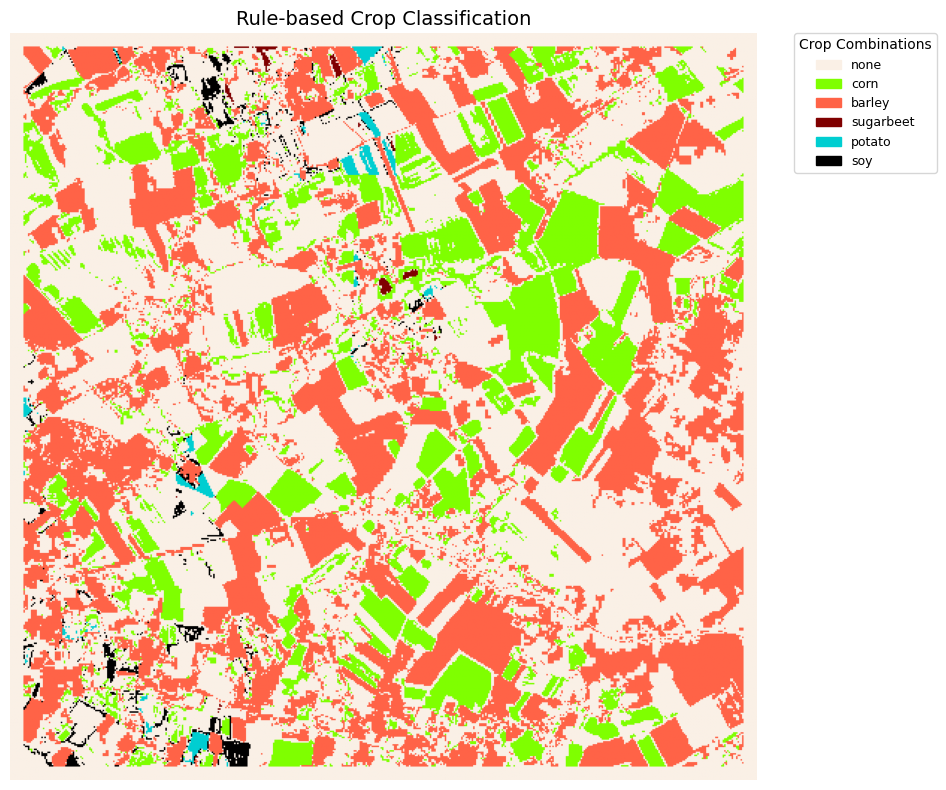

In [26]:
col_palette = [
    "linen",
    "chartreuse",
    "tomato",
    "olivedrab",
    "maroon",
    "whitesmoke",
    "wheat",
    "palevioletred",
    "darkturquoise",
    "tomato",
    "thistle",
    "teal",
    "darkgoldenrod",
    "darkmagenta",
    "darkorange",
    "sienna",
    "black",
    "silver",
    "tan",
    "seagreen",
    "mediumspringgreen",
    "lightseagreen",
    "royalblue",
    "mediumpurple",
    "plum",
    "darkcyan",
    "moccasin",
    "rosybrown",
    "gray",
    "sandybrown",
    "magenta",
    "navy",
]

comb = {
    0: "none",
    1: "corn",
    2: "barley",
    3: "corn barley",
    4: "sugarbeet",
    5: "sugarbeet corn",
    6: "sugarbeet barley",
    7: "sugarbeet barley corn",
    8: "potato",
    9: "potato corn",
    10: "potato barley",
    11: "potato barley corn",
    12: "potato sugarbeet",
    13: "potato sugarbeet corn",
    14: "potato sugarbeet barley",
    15: "potato sugarbeet barley corn",
    16: "soy",
    17: "soy corn",
    18: "soy barley",
    19: "soy barley corn",
    20: "soy sugarbeet",
    21: "soy sugarbeet corn",
    22: "soy sugarbeet barley",
    23: "soy sugarbeet barley corn",
    24: "soy potato",
    25: "soy potato corn",
    26: "soy potato barley",
    27: "soy potato barley corn",
    28: "soy potato sugarbeet",
    29: "soy potato sugarbeet corn",
    30: "soy potato sugarbeet barley",
    31: "soy potato sugarbeet barley corn",
}

ds = np.where(np.isin(total_scaled, [1, 2, 4, 8, 16]), total_scaled, 0)

keys = np.unique(ds).astype(int)
labels = [comb[k] for k in keys]

colors = [col_palette[k] for k in keys]  # keep same color index as class
cmap = ListedColormap(colors)
class_bins = [-0.5] + [k + 0.5 for k in keys]
norm = BoundaryNorm(class_bins, len(colors))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(ds, cmap=cmap, norm=norm)
ax.set_title("Rule-based Crop Classification", fontsize=14)
ax.axis("off")

legend_patches = [Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
ax.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=9,
    title="Crop Combinations",
)

plt.tight_layout()
plt.show()